n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      299 |      1 |  2.0000000000 |  5.218722E+03 |             - |             -
     2 |      599 |      1 |  0.000000E+00 |  6.553342E+02 |             - |             -
     3 |      899 |      5 |  0.000000E+00 |  1.326973E+02 |  0.9883640041 |         ideal
     4 |     1199 |     10 |  0.000000E+00 |  5.888383E+01 |  0.0962632032 |         ideal
     5 |     1499 |     13 |  0.000000E+00 |  1.369103E+01 |  0.2968327678 |         ideal
     6 |     1799 |     31 |  0.000000E+00 |  0.7797204820 |  0.0880967917 |         ideal
     7 |     2099 |     65 |  0.000000E+00 |  0.000000E+00 |  0.0383377855 |         ideal
     8 |     2399 |     94 |  0.000000E+00 |  0.000000E+00 |  0.0164749828 |         ideal
     9 |     2699 |    131 |  0.000000E+00 |  0.000000E+00 |  0.0272348766 |         ideal
    10 |     2999 |    163 |  0.000000E+00 |  0.000000E+00 |  0.1206927488 |         ideal

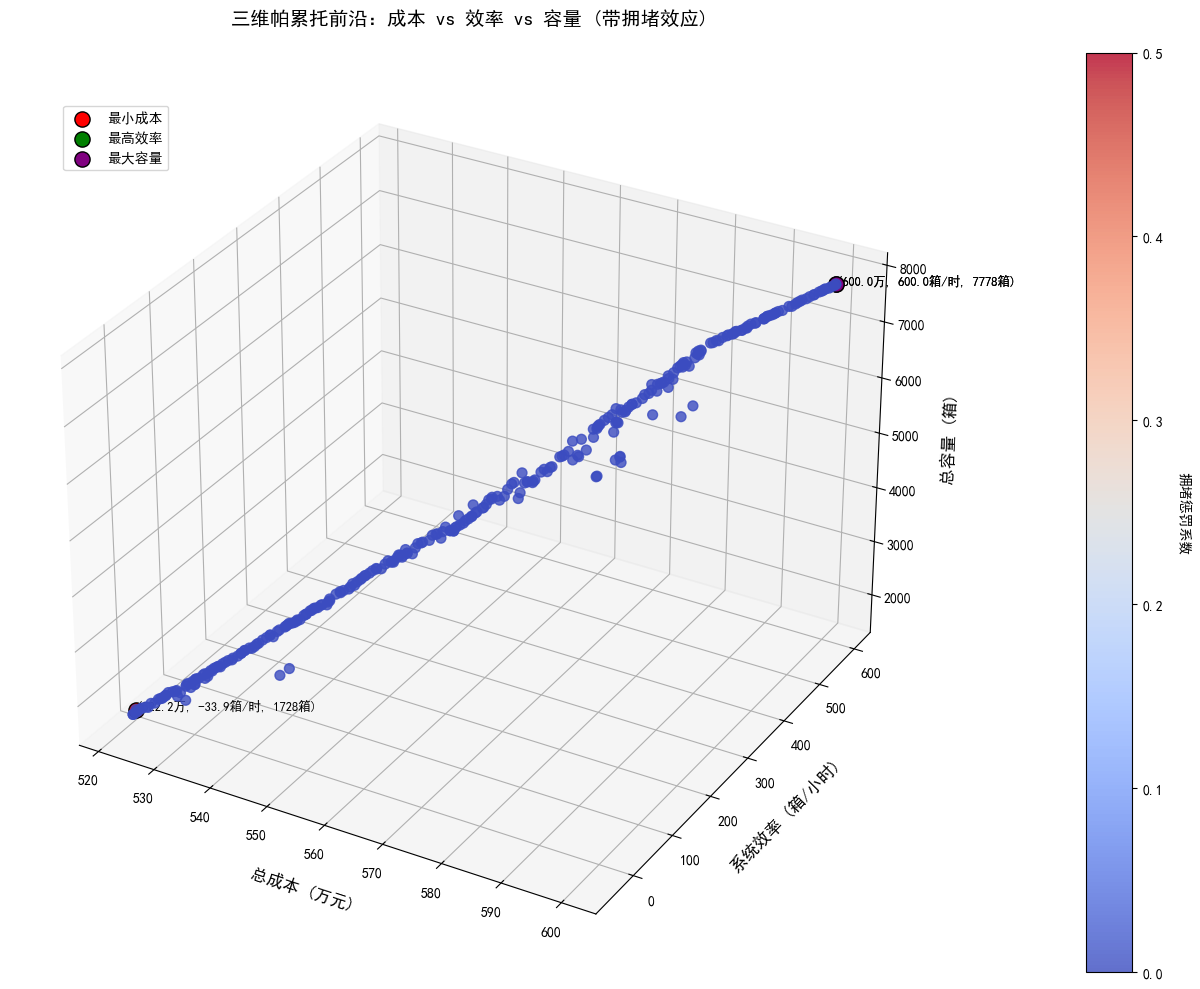

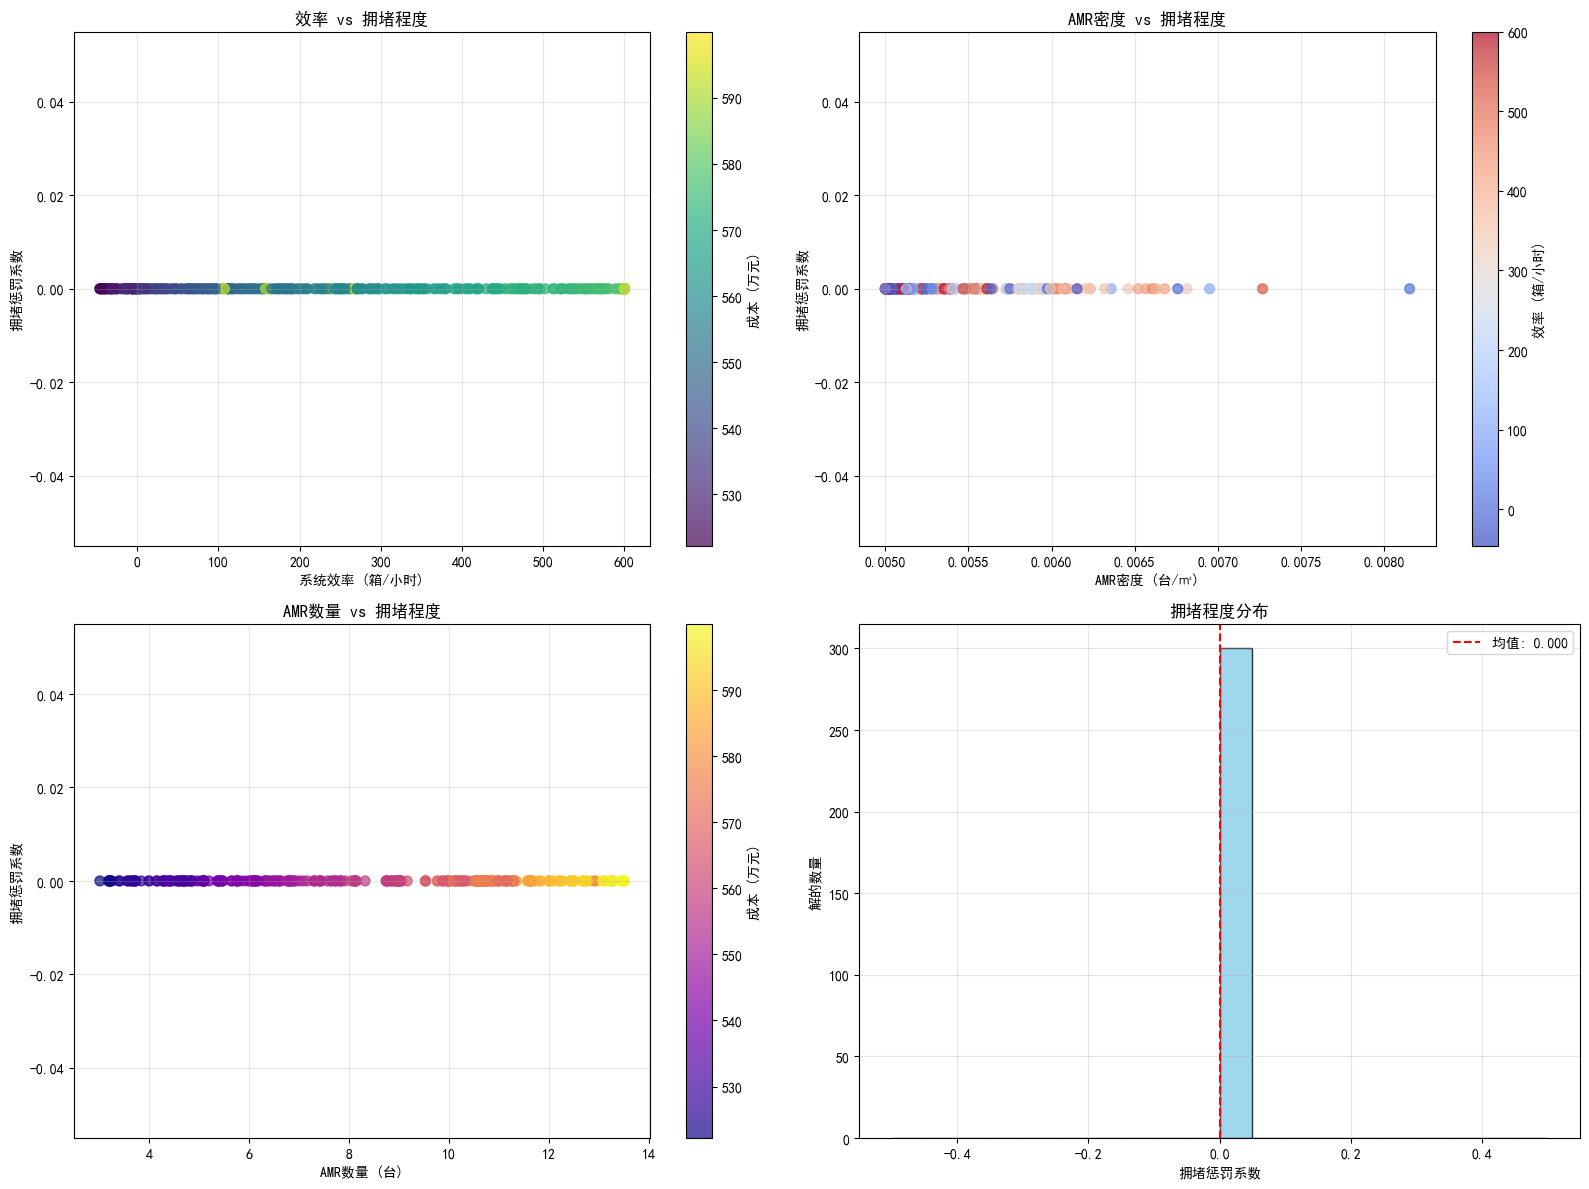


帕累托解集示例（成本≤1200万）：
解1: N_arm=4.500991885377653, N_amr=13.50332634434629, N_old=0.01539847670285715, N_columns=27.005951312265918, η_new=1.00 | Cost=600.0万, Eff=600.0箱/小时, Cap=7778箱, Congestion=0.000
解2: N_arm=1.0000006214288764, N_amr=3.006786768532841, N_old=3.096359870976076e-11, N_columns=6.000003728573258, η_new=0.77 | Cost=522.2万, Eff=-33.9箱/小时, Cap=1728箱, Congestion=0.000
解3: N_arm=1.0060902873374555, N_amr=3.1862694612320808, N_old=0.0006760289807888516, N_columns=6.036541724024733, η_new=1.00 | Cost=522.7万, Eff=-46.2箱/小时, Cap=1739箱, Congestion=0.000
解4: N_arm=4.500991885377653, N_amr=13.50332634434629, N_old=0.01539847670285715, N_columns=27.005951312265918, η_new=1.00 | Cost=600.0万, Eff=600.0箱/小时, Cap=7778箱, Congestion=0.000
解5: N_arm=3.90069998045195, N_amr=11.824447833056386, N_old=0.00020340608233144575, N_columns=23.4041998827117, η_new=1.00 | Cost=586.8万, Eff=600.0箱/小时, Cap=6740箱, Congestion=0.000
解6: N_arm=1.2580077344875158, N_amr=4.443743964010213, N_old=0.00125994229

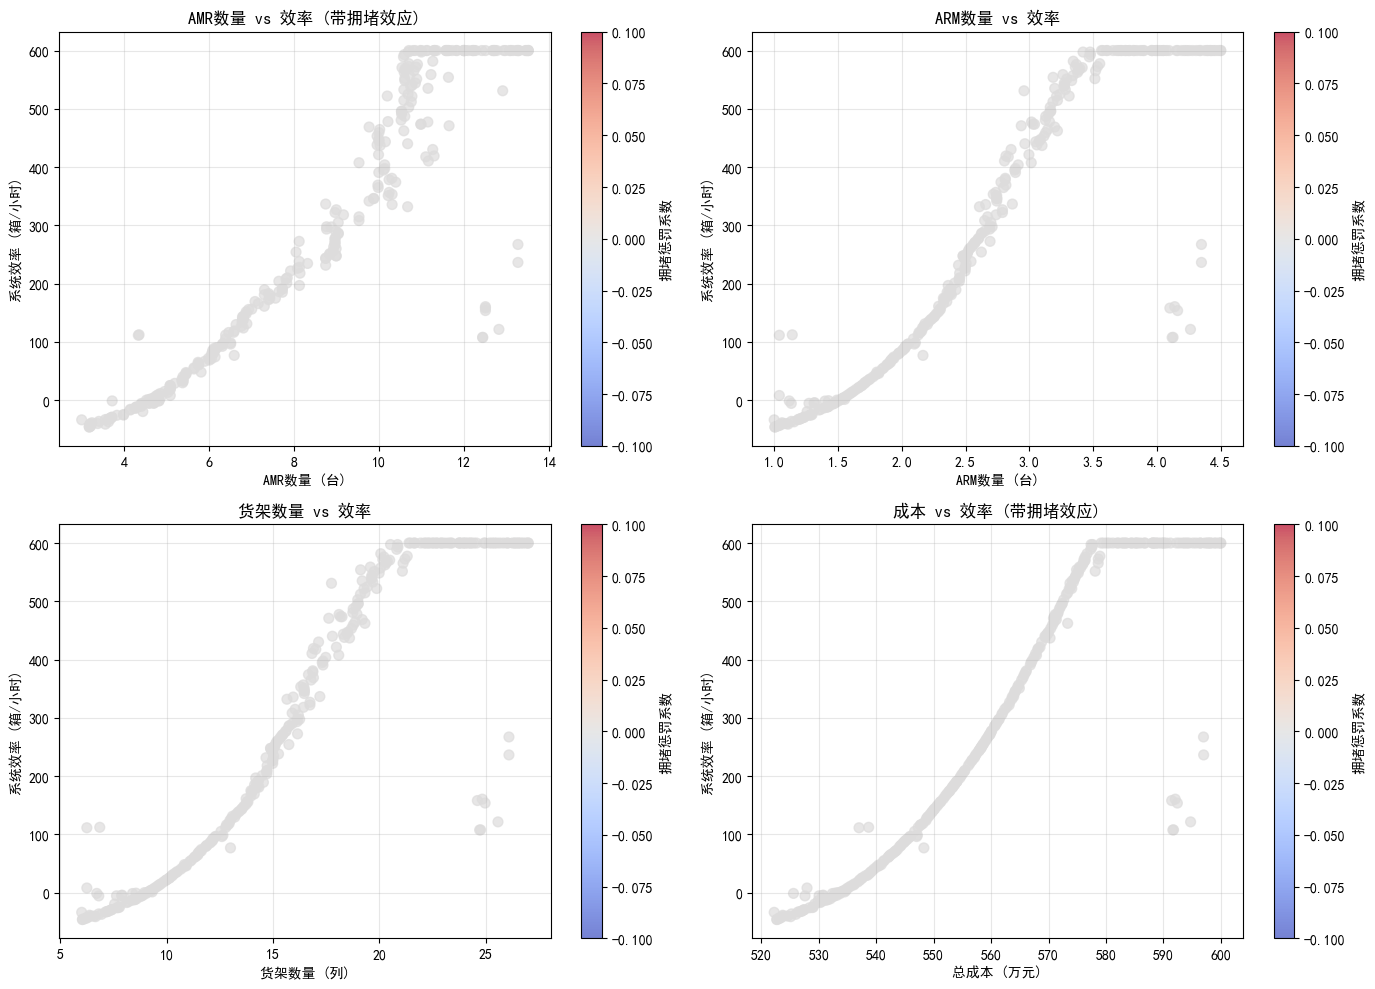

In [20]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ========================== 外部参数配置 ==========================
# 设备成本参数
C_arm = 15    # 大机器人单价（万元/台）
C_amr = 2     # 小机器人单价（万元/台）
C_old_mod = 5 # 旧机器人改造单价（万元/台）
C_rack = 0.2  # 单列货架成本（万元/列）
C_land = 0.1  # 场地成本（万元/㎡）
A_total = 5000 # 仓库总面积（㎡）
k = 100       # 单列货架占地面积（㎡/列）
MAX_COST = 600  # 成本上限约束（万元）

# 效率参数
alpha = 60    # 旧机器人单位处理量（箱/小时）
beta = 0.2    # 面积衰减系数
v_vertical = 2   # 大机器人垂直速度（m/s）
H_avg = 15    # 平均存储高度（m）
mu = 1        # 操作效率系数
v_horizontal = 3 # 小机器人水平速度（m/s）
D_avg = 50    # 缓存区到工作站平均距离（m）
TaskRate = 200  # 单位时间料箱处理需求（箱/小时）
gamma = 0.1   # 缓存阻塞惩罚系数
manual_time_per_box = 6 / 3600  # 人工操作时间（小时/箱）

# 拥堵参数
congestion_factor = 0.005  # 拥堵系数（控制拥堵效应强度）
min_amr_area = 10         # 每台AMR最小占用面积（㎡）
max_congestion_penalty = 0.5  # 最大拥堵惩罚（效率下降不超过50%）

# 决策变量范围
arm_range = [1, 30]     # N_arm范围
amr_range = [1, 100]    # N_amr范围
old_range = [0, 50]     # N_old范围
eta_range = [0.0, 1.0]  # η_new范围

# ========================== 定义优化问题 ==========================
class WarehouseProblem(ElementwiseProblem):
    def __init__(self):
        # 决策变量定义：4个变量（3个整数+1个连续）
        super().__init__(
            n_var=4,
            n_obj=3,  # 三个目标：成本、效率、容量
            n_ieq_constr=3,  # 三个不等式约束
            xl=np.array([arm_range[0], amr_range[0], old_range[0], eta_range[0]]),
            xu=np.array([arm_range[1], amr_range[1], old_range[1], eta_range[1]]),
            vtype=[int, int, int, float]  # 变量类型
        )
    
    def _evaluate(self, x, out, *args, **kwargs):
        # 解析决策变量
        N_arm, N_amr, N_old, eta_new = x
        N_columns = 6 * N_arm  # 货架数量为6*N_arm
        eta_old = 1 - eta_new
        
        # ---- 约束条件计算 ----
        g1 = 3 * N_arm - N_amr  # 要求：N_amr >= 3*N_arm → g1 <= 0
        A_new = k * N_columns
        A_old = A_total - A_new
        
        # ---- 目标1：成本计算（最小化） ----
        cost = (
            C_arm * N_arm + 
            C_amr * N_amr +
            C_old_mod * N_old +
            C_rack * N_columns +
            C_land * A_total
        )
        
        # ---- 成本约束 ----
        g2 = cost - MAX_COST  # 成本不能超过MAX_COST
        
        # ---- 区域面积约束 ----
        g3 = A_new - A_total  # 新系统区域面积不能超过总面积 → g3 <= 0
        
        # ---- 目标2：效率计算（最大化） ----
        # 旧系统效率
        OldSysEff = N_old * alpha * (1 - beta * A_old / A_total) if A_old > 0 else 0
        
        # 新系统效率
        ArmEff = N_arm * (v_vertical / H_avg) * mu * 3600  # 转换为箱/小时
        
        # 计算AMR拥堵效应
        available_area_per_amr = A_new / max(1, N_amr)  # 每台AMR可用面积
        congestion_penalty = min(
            max_congestion_penalty,
            congestion_factor * max(0, min_amr_area * N_amr - A_new)
        )
        congestion_factor_amr = 1 - congestion_penalty
        
        # AMR基础效率
        AmrEff_base = N_amr * (v_horizontal / D_avg) * (A_new / A_total) * 3600
        
        # 应用拥堵效应
        AmrEff = AmrEff_base * congestion_factor_amr
        
        # 缓存阻塞率计算（更合理的公式）
        max_throughput = 2 * N_columns
        if max_throughput > 0:
            CacheBlockRate = max(0, (TaskRate - max_throughput) / max_throughput)
        else:
            CacheBlockRate = 1  # 无货架时阻塞率100%
        
        # 效率瓶颈模型：取Arm和Amr中的最小值，并考虑阻塞惩罚
        NewSysEff = min(ArmEff, AmrEff) * (1 - gamma * CacheBlockRate)
        
        # 综合效率（加权和）
        efficiency = eta_new * NewSysEff + eta_old * OldSysEff
        
        # 考虑人工操作时间限制
        max_manual_capacity = 1 / manual_time_per_box  # 人工最大处理能力（箱/小时）
        efficiency = min(efficiency, max_manual_capacity)
        
        # ---- 目标3：总容量计算（最大化） ----
        capacity = 288 * N_columns + 27 * N_old
        
        # ---- 输出结果 ----
        out["F"] = [cost, -efficiency, -capacity]  # 效率与容量取负
        out["G"] = [g1, g2, g3]  # 三个约束
        # 保存中间变量用于分析
        out["congestion_penalty"] = congestion_penalty
        out["amr_area"] = available_area_per_amr

# ========================== 优化执行 ==========================
problem = WarehouseProblem()

# 改进算法配置
algorithm = NSGA2(
    pop_size=300,  # 增加种群大小以捕获更多多样性
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),  # 调整交叉参数
    mutation=PM(eta=20, prob=0.15),   # 增加变异概率
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 500)  # 增加迭代次数

# 执行优化
res = minimize(
    problem,
    algorithm,
    termination,
    seed=42,  # 固定随机种子确保可重复性
    verbose=True,
    save_history=True  # 保存历史用于收敛分析
)

# ========================== 结果分析与可视化 ==========================
# 提取三目标结果并转换回正值
F = res.F
F[:, 1] = -F[:, 1]  # 效率转回正值
F[:, 2] = -F[:, 2]  # 容量转回正值

# 提取拥堵数据
congestion_data = [res.pop[i].data.get("congestion_penalty", 0) for i in range(len(res.pop))]
amr_area_data = [res.pop[i].data.get("amr_area", 0) for i in range(len(res.pop))]

# 筛选可行解（满足所有约束）
feasible_mask = np.all(res.G <= 0, axis=1)
feasible_F = F[feasible_mask]
feasible_X = [res.pop[i].X for i in range(len(res.pop)) if feasible_mask[i]]
feasible_congestion = np.array(congestion_data)[feasible_mask]
feasible_amr_area = np.array(amr_area_data)[feasible_mask]

if len(feasible_F) == 0:
    raise RuntimeError("未找到可行解！请检查约束条件或调整参数范围")

# 绘制3D帕累托前沿（带拥堵效应可视化）
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# 根据拥堵程度着色
sc = ax.scatter(feasible_F[:, 0], feasible_F[:, 1], feasible_F[:, 2], 
                c=feasible_congestion, cmap='coolwarm', 
                marker='o', s=50, alpha=0.8, depthshade=True,
                vmin=0, vmax=max_congestion_penalty)

# 设置坐标轴标签
ax.set_xlabel('总成本 (万元)', fontsize=12, labelpad=10)
ax.set_ylabel('系统效率 (箱/小时)', fontsize=12, labelpad=10)
ax.set_zlabel('总容量 (箱)', fontsize=12, labelpad=10)
plt.title(f"三维帕累托前沿：成本 vs 效率 vs 容量 (带拥堵效应)", fontsize=14, pad=20)
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('拥堵惩罚系数', rotation=270, labelpad=20)

# 标注典型解
def annotate_point(idx, color, label):
    ax.scatter(feasible_F[idx, 0], feasible_F[idx, 1], feasible_F[idx, 2], 
               s=120, c=color, edgecolors='k', label=label)
    ax.text(feasible_F[idx, 0], feasible_F[idx, 1], feasible_F[idx, 2], 
            f'({feasible_F[idx, 0]:.1f}万, {feasible_F[idx, 1]:.1f}箱/时, {feasible_F[idx, 2]:.0f}箱)', 
            fontsize=9, color='k')

idx_min_cost = np.argmin(feasible_F[:, 0])
idx_max_eff = np.argmax(feasible_F[:, 1])
idx_max_cap = np.argmax(feasible_F[:, 2])

annotate_point(idx_min_cost, 'red', '最小成本')
annotate_point(idx_max_eff, 'green', '最高效率')
annotate_point(idx_max_cap, 'purple', '最大容量')

plt.legend(loc='upper left', bbox_to_anchor=(0.05, 0.95))
plt.tight_layout()
plt.savefig('pareto_front_3d_congestion.png', dpi=300, bbox_inches='tight')
plt.show()

# 绘制拥堵效应分析图
plt.figure(figsize=(16, 12))

# 拥堵程度与效率关系
plt.subplot(2, 2, 1)
plt.scatter(feasible_F[:, 1], feasible_congestion, c=feasible_F[:, 0], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='成本 (万元)')
plt.xlabel('系统效率 (箱/小时)')
plt.ylabel('拥堵惩罚系数')
plt.title('效率 vs 拥堵程度')
plt.grid(True, alpha=0.3)

# AMR密度与拥堵程度关系
amr_density = [1/area if area > 0 else 0 for area in feasible_amr_area]
plt.subplot(2, 2, 2)
plt.scatter(amr_density, feasible_congestion, c=feasible_F[:, 1], cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label='效率 (箱/小时)')
plt.xlabel('AMR密度 (台/㎡)')
plt.ylabel('拥堵惩罚系数')
plt.title('AMR密度 vs 拥堵程度')
plt.grid(True, alpha=0.3)

# AMR数量与拥堵程度关系
plt.subplot(2, 2, 3)
plt.scatter([x[1] for x in feasible_X], feasible_congestion, c=feasible_F[:, 0], cmap='plasma', s=50, alpha=0.7)
plt.colorbar(label='成本 (万元)')
plt.xlabel('AMR数量 (台)')
plt.ylabel('拥堵惩罚系数')
plt.title('AMR数量 vs 拥堵程度')
plt.grid(True, alpha=0.3)

# 拥堵程度分布
plt.subplot(2, 2, 4)
plt.hist(feasible_congestion, bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(x=np.mean(feasible_congestion), color='r', linestyle='--', 
            label=f'均值: {np.mean(feasible_congestion):.3f}')
plt.xlabel('拥堵惩罚系数')
plt.ylabel('解的数量')
plt.title('拥堵程度分布')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('congestion_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================== 解集分析 ==========================
# 计算容量-成本比（箱/万元）
capacity_cost_ratio = feasible_F[:, 2] / feasible_F[:, 0]
idx_best_ratio = np.argmax(capacity_cost_ratio)

# 计算效率-成本比（箱/小时/万元）
efficiency_cost_ratio = feasible_F[:, 1] / feasible_F[:, 0]
idx_best_efficiency_ratio = np.argmax(efficiency_cost_ratio)

# 输出最优解集
print("\n帕累托解集示例（成本≤1200万）：")
for i in range(min(10, len(feasible_X))):
    X = feasible_X[i]
    N_columns = 6 * X[0]  # 货架数量
    congestion = feasible_congestion[i]
    print(f"解{i+1}: "
          f"N_arm={X[0]}, N_amr={X[1]}, N_old={X[2]}, "
          f"N_columns={N_columns}, η_new={X[3]:.2f} | "
          f"Cost={feasible_F[i,0]:.1f}万, Eff={feasible_F[i,1]:.1f}箱/小时, "
          f"Cap={feasible_F[i,2]:.0f}箱, Congestion={congestion:.3f}")

# 输出高性价比解
best_ratio_sol = feasible_X[idx_best_ratio]
N_columns_ratio = 6 * best_ratio_sol[0]
congestion_ratio = feasible_congestion[idx_best_ratio]
print(f"\n最佳容量成本比解: "
      f"N_arm={best_ratio_sol[0]}, N_amr={best_ratio_sol[1]}, N_old={best_ratio_sol[2]}, "
      f"N_columns={N_columns_ratio}, η_new={best_ratio_sol[3]:.2f} | "
      f"Cost={feasible_F[idx_best_ratio,0]:.1f}万, "
      f"Cap={feasible_F[idx_best_ratio,2]:.0f}箱, "
      f"Congestion={congestion_ratio:.3f}, "
      f"Ratio={capacity_cost_ratio[idx_best_ratio]:.2f}箱/万元")

# 输出高效率成本比解
best_efficiency_ratio_sol = feasible_X[idx_best_efficiency_ratio]
N_columns_efficiency = 6 * best_efficiency_ratio_sol[0]
congestion_eff = feasible_congestion[idx_best_efficiency_ratio]
print(f"\n最佳效率成本比解: "
      f"N_arm={best_efficiency_ratio_sol[0]}, N_amr={best_efficiency_ratio_sol[1]}, "
      f"N_old={best_efficiency_ratio_sol[2]}, N_columns={N_columns_efficiency}, "
      f"η_new={best_efficiency_ratio_sol[3]:.2f} | "
      f"Cost={feasible_F[idx_best_efficiency_ratio,0]:.1f}万, "
      f"Eff={feasible_F[idx_best_efficiency_ratio,1]:.1f}箱/小时, "
      f"Congestion={congestion_eff:.3f}, "
      f"Ratio={efficiency_cost_ratio[idx_best_efficiency_ratio]:.2f}箱/小时/万元")

# 分析结果范围
print("\n优化结果范围分析（成本≤1200万）:")
print(f"成本范围: {min(feasible_F[:, 0]):.1f} - {max(feasible_F[:, 0]):.1f} 万元")
print(f"效率范围: {min(feasible_F[:, 1]):.1f} - {max(feasible_F[:, 1]):.1f} 箱/小时")
print(f"容量范围: {min(feasible_F[:, 2]):.0f} - {max(feasible_F[:, 2]):.0f} 箱")
print(f"拥堵惩罚范围: {min(feasible_congestion):.3f} - {max(feasible_congestion):.3f}")
print(f"可行解数量: {len(feasible_F)}")

# 拥堵效应分析
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.scatter([x[1] for x in feasible_X], feasible_F[:, 1], c=feasible_congestion, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label='拥堵惩罚系数')
plt.xlabel('AMR数量 (台)')
plt.ylabel('系统效率 (箱/小时)')
plt.title('AMR数量 vs 效率 (带拥堵效应)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter([x[0] for x in feasible_X], feasible_F[:, 1], c=feasible_congestion, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label='拥堵惩罚系数')
plt.xlabel('ARM数量 (台)')
plt.ylabel('系统效率 (箱/小时)')
plt.title('ARM数量 vs 效率')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.scatter([6*x[0] for x in feasible_X], feasible_F[:, 1], c=feasible_congestion, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label='拥堵惩罚系数')
plt.xlabel('货架数量 (列)')
plt.ylabel('系统效率 (箱/小时)')
plt.title('货架数量 vs 效率')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(feasible_F[:, 0], feasible_F[:, 1], c=feasible_congestion, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label='拥堵惩罚系数')
plt.xlabel('总成本 (万元)')
plt.ylabel('系统效率 (箱/小时)')
plt.title('成本 vs 效率 (带拥堵效应)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficiency_congestion_analysis.png', dpi=300, bbox_inches='tight')
plt.show()